In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = '0'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.2'

import numpy as np

import matplotlib.pyplot as plt

import torch
torch.serialization.add_safe_globals([slice])  # allow this builtin during torch.load

# Set default tensor type to float32 to avoid dtype issues
torch.set_default_dtype(torch.float32)

from e3nn import o3

import torch
import numpy as np
from torch_geometric.data import Data
from typing import List, Tuple, Dict

In [2]:
from openqdc.datasets import RevMD17

positions = []
energies = []
species = []

n_samples = 6000

dataset = RevMD17(
    energy_unit="kcal/mol",
    distance_unit="ang",
    array_format = "torch"
)

first_entry = dataset[0] 
for data in dataset.as_iter():
    positions.append(data.positions)
    energies.append(data.energies)
    species.append(data.atomic_numbers)
    
    if len(positions) % 100 == 0:
        print(f"{data.name}")
    
    if len(positions) >= n_samples:
        break
    
positions = torch.stack(positions)
energies = torch.stack(energies)
species = torch.stack(species)

# Convert to float32 to match model expectations
positions = positions.float()
energies = energies.float()
species = species.long()  # Keep as long for species indices

print(f"Data types after conversion:")
print(f"Positions: {positions.dtype}, shape: {positions.shape}")
print(f"Energies: {energies.dtype}, shape: {energies.shape}")
print(f"Species: {species.dtype}, shape: {species.shape}")

2025-09-23 16:51:05.666 | INFO     | openqdc.datasets.base:read_preprocess:435 - Reading preprocessed data.
2025-09-23 16:51:05.668 | INFO     | openqdc.datasets.base:read_preprocess:436 - Dataset revmd17 with the following units:
                     Energy: kcal/mol,
                     Distance: ang,
                     Forces: kcal/mol/ang
2025-09-23 16:51:05.776 | INFO     | openqdc.datasets.base:read_preprocess:452 - Loaded atomic_inputs with shape (15599712, 5), dtype float32
2025-09-23 16:51:05.777 | INFO     | openqdc.datasets.base:read_preprocess:452 - Loaded position_idx_range with shape (999988, 2), dtype int32
2025-09-23 16:51:05.778 | INFO     | openqdc.datasets.base:read_preprocess:452 - Loaded energies with shape (999988, 1), dtype float64
2025-09-23 16:51:05.778 | INFO     | openqdc.datasets.base:read_preprocess:452 - Loaded forces with shape (15599712, 3, 1), dtype float32
2025-09-23 16:51:05.779 | INFO     | openqdc.datasets.base:read_preprocess:452 - Loaded subset

CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O
CC(=O)OC1=CC=CC=C1C(=O)O


In [5]:
first_entry.name

'CC(=O)OC1=CC=CC=C1C(=O)O'

In [6]:
positions.shape, energies.shape, species.shape

# Check what species are in the dataset
print("Species information:")
print(f"Species shape: {species.shape}")
print(f"Unique atomic numbers in first sample: {torch.unique(species[0])}")
print(f"All unique atomic numbers: {torch.unique(species.flatten())}")
print(f"Number of unique species: {len(torch.unique(species.flatten()))}")

Species information:
Species shape: torch.Size([6000, 21])
Unique atomic numbers in first sample: tensor([1, 6, 8])
All unique atomic numbers: tensor([1, 6, 8])
Number of unique species: 3


In [7]:
# Determine number of species for model
unique_atomic_numbers = torch.unique(species.flatten())
num_species = len(unique_atomic_numbers)
print(f"Creating model with {num_species} species: {unique_atomic_numbers.tolist()}")

# Create species mapping for reference
species_mapping = {atomic_num.item(): idx for idx, atomic_num in enumerate(unique_atomic_numbers)}
print(f"Species mapping: {species_mapping}")


Creating model with 3 species: [1, 6, 8]
Species mapping: {1: 0, 6: 1, 8: 2}


In [128]:
def process_md17_data(positions, energies, species_data, r_cut=8.0, max_neighbors=50):
    """
    Process MD17 data into format expected by ACE model training.
    
    Args:
        positions: [n_samples, n_atoms, 3] - atomic positions  
        energies: [n_samples] - total energies
        species_data: [n_samples, n_atoms] - atomic numbers
        r_cut: cutoff radius for neighbor finding
        max_neighbors: maximum number of neighbors to consider
        
    Returns:
        data_list: list of torch_geometric.data.Data objects
        metadata: dict with processing information
    """
    data_list = []
    
    # Find unique species and create mapping
    all_species = torch.cat([species_data[i].flatten() for i in range(len(species_data))])
    unique_species = torch.unique(all_species).tolist()
    species_to_idx = {species: idx for idx, species in enumerate(unique_species)}
    
    print(f"Found {len(unique_species)} unique species: {unique_species}")
    print(f"Species mapping: {species_to_idx}")
    
    total_edges = 0
    max_edges_per_structure = 0
    
    for i in range(len(positions)):
        pos = positions[i]  # [n_atoms, 3]
        energy = energies[i] if energies.dim() > 0 else energies  # scalar or [1]
        atomic_numbers = species_data[i]  # [n_atoms]
        
        n_atoms = pos.shape[0]
        
        # Convert atomic numbers to species indices
        species = torch.tensor([species_to_idx[atomic_numbers[j].item()] 
                              for j in range(n_atoms)], dtype=torch.long)
        
        # Build adjacency list and edge attributes
        edge_indices_i = []
        edge_indices_j = []
        edge_vectors = []
        edge_lengths = []
        edge_species_i = []
        edge_species_j = []
        
        for center_idx in range(n_atoms):
            center_pos = pos[center_idx]  # [3]
            center_species_idx = species[center_idx].item()
            
            # Calculate distances to all other atoms
            distances = torch.norm(pos - center_pos.unsqueeze(0), dim=1)  # [n_atoms]
            
            # Find neighbors within cutoff (excluding self)
            neighbor_mask = (distances > 0.1) & (distances <= r_cut)
            neighbor_indices = torch.where(neighbor_mask)[0]
            
            if len(neighbor_indices) == 0:
                continue  # Skip atoms with no neighbors
                
            # Limit number of neighbors
            if len(neighbor_indices) > max_neighbors:
                neighbor_distances = distances[neighbor_indices]
                _, closest_indices = torch.topk(neighbor_distances, max_neighbors, largest=False)
                neighbor_indices = neighbor_indices[closest_indices]
            
            # Store edge information
            n_neighbors = len(neighbor_indices)
            edge_indices_i.extend([center_idx] * n_neighbors)
            edge_indices_j.extend(neighbor_indices.tolist())
            
            # Edge vectors and distances
            neighbor_positions = pos[neighbor_indices]
            vectors = neighbor_positions - center_pos.unsqueeze(0)
            edge_vectors.append(vectors)
            edge_lengths.append(distances[neighbor_indices])
            
            # Species information
            edge_species_i.extend([center_species_idx] * n_neighbors)
            edge_species_j.extend(species[neighbor_indices].tolist())
        
        # Convert to tensors
        if len(edge_indices_i) > 0:
            edge_index = torch.tensor([edge_indices_i, edge_indices_j], dtype=torch.long)
            edge_vec = torch.cat(edge_vectors, dim=0)  # [n_edges, 3]
            edge_len = torch.cat(edge_lengths, dim=0)  # [n_edges]
            edge_spec_i = torch.tensor(edge_species_i, dtype=torch.long)  # [n_edges]
            edge_spec_j = torch.tensor(edge_species_j, dtype=torch.long)  # [n_edges]
            
            # Unit directions
            edge_dir = edge_vec / (edge_len.unsqueeze(-1) + 1e-10)  # [n_edges, 3]
            
            n_edges = edge_index.shape[1]
            total_edges += n_edges
            max_edges_per_structure = max(max_edges_per_structure, n_edges)
        else:
            # Handle case with no edges (isolated atoms)
            edge_index = torch.zeros((2, 0), dtype=torch.long)
            edge_vec = torch.zeros((0, 3))
            edge_len = torch.zeros(0)
            edge_dir = torch.zeros((0, 3))
            edge_spec_i = torch.zeros(0, dtype=torch.long)
            edge_spec_j = torch.zeros(0, dtype=torch.long)
        
        # Create PyTorch Geometric data object
        data = Data(
            # Node features
            pos=pos,                           # [n_atoms, 3] - positions
            species=species,                   # [n_atoms] - species indices
            atomic_numbers=atomic_numbers,     # [n_atoms] - original atomic numbers
            
            # Graph connectivity
            edge_index=edge_index,             # [2, n_edges] - connectivity
            edge_vec=edge_vec,                 # [n_edges, 3] - edge vectors
            edge_len=edge_len,                 # [n_edges] - edge lengths
            edge_dir=edge_dir,                 # [n_edges, 3] - unit directions
            edge_species_i=edge_spec_i,        # [n_edges] - center atom species
            edge_species_j=edge_spec_j,        # [n_edges] - neighbor atom species
            
            # Target properties
            energy=energy,                     # scalar - total energy
            
            # Metadata
            num_atoms=n_atoms,
            structure_idx=i
        )
        
        data_list.append(data)
    
    metadata = {
        'unique_species': unique_species,
        'species_to_idx': species_to_idx,
        'num_species': len(unique_species),
        'r_cut': r_cut,
        'max_neighbors': max_neighbors,
        'total_structures': len(data_list),
        'avg_edges_per_structure': total_edges / len(data_list) if data_list else 0,
        'max_edges_per_structure': max_edges_per_structure
    }
    
    return data_list, metadata


def split_data(data_list: List[Data], train_ratio=0.8, random_seed=42):
    """
    Split processed data into train and test sets.
    
    Args:
        data_list: list of torch_geometric.data.Data objects
        train_ratio: fraction of data to use for training
        random_seed: random seed for reproducibility
        
    Returns:
        train_data, test_data: split datasets
    """
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)
    
    n_samples = len(data_list)
    n_train = int(n_samples * train_ratio)
    
    # Shuffle indices
    indices = torch.randperm(n_samples)
    train_indices = indices[:n_train]
    test_indices = indices[n_train:]
    
    train_data = [data_list[i] for i in train_indices]
    test_data = [data_list[i] for i in test_indices]
    
    return train_data, test_data


def create_data_loaders(train_data: List[Data], test_data: List[Data], 
                       batch_size=32, shuffle_train=True):
    """
    Create PyTorch Geometric data loaders for training and testing.
    
    Args:
        train_data, test_data: lists of Data objects
        batch_size: batch size for data loading
        shuffle_train: whether to shuffle training data
        
    Returns:
        train_loader, test_loader: DataLoader objects
    """
    from torch_geometric.loader import DataLoader
    
    train_loader = DataLoader(
        train_data, 
        batch_size=batch_size, 
        shuffle=shuffle_train,
        follow_batch=['species', 'edge_species_i', 'edge_species_j']  # Track batch indices
    )
    
    test_loader = DataLoader(
        test_data, 
        batch_size=batch_size, 
        shuffle=False,
        follow_batch=['species', 'edge_species_i', 'edge_species_j']
    )
    
    return train_loader, test_loader


def compute_dataset_statistics(data_list: List[Data], metadata: Dict):
    """
    Compute useful statistics for the dataset.
    
    Args:
        data_list: list of Data objects
        metadata: metadata dictionary
        
    Returns:
        stats: dictionary with dataset statistics
    """
    energies = torch.stack([data.energy for data in data_list])
    
    # Edge length statistics
    all_edge_lengths = torch.cat([data.edge_len for data in data_list if data.edge_len.numel() > 0])
    
    # Atom count statistics
    atom_counts = [data.num_atoms for data in data_list]
    
    stats = {
        'energy_mean': energies.mean().item(),
        'energy_std': energies.std().item(),
        'energy_min': energies.min().item(),
        'energy_max': energies.max().item(),
        
        'edge_len_mean': all_edge_lengths.mean().item(),
        'edge_len_std': all_edge_lengths.std().item(),
        'edge_len_min': all_edge_lengths.min().item(),
        'edge_len_max': all_edge_lengths.max().item(),
        
        'atoms_per_structure_mean': np.mean(atom_counts),
        'atoms_per_structure_std': np.std(atom_counts),
        'min_atoms': min(atom_counts),
        'max_atoms': max(atom_counts),
        
        'total_atoms': sum(atom_counts),
        'total_edges': sum(data.edge_index.shape[1] for data in data_list)
    }
    
    return stats


def print_dataset_info(metadata: Dict, stats: Dict):
    """Print comprehensive dataset information."""
    print("\n" + "="*60)
    print("DATASET INFORMATION")
    print("="*60)
    
    print(f"Structures: {metadata['total_structures']}")
    print(f"Species: {metadata['unique_species']} (mapping: {metadata['species_to_idx']})")
    print(f"Cutoff radius: {metadata['r_cut']} Å")
    print(f"Max neighbors: {metadata['max_neighbors']}")
    
    print(f"\nAtoms per structure: {stats['min_atoms']}-{stats['max_atoms']} "
          f"(avg: {stats['atoms_per_structure_mean']:.1f} ± {stats['atoms_per_structure_std']:.1f})")
    print(f"Total atoms: {stats['total_atoms']}")
    
    print(f"\nEdges per structure: avg {metadata['avg_edges_per_structure']:.1f}, "
          f"max {metadata['max_edges_per_structure']}")
    print(f"Total edges: {stats['total_edges']}")
    
    print(f"\nEnergies: {stats['energy_min']:.3f} to {stats['energy_max']:.3f} eV "
          f"(mean: {stats['energy_mean']:.3f} ± {stats['energy_std']:.3f})")
    
    print(f"\nEdge lengths: {stats['edge_len_min']:.3f} to {stats['edge_len_max']:.3f} Å "
          f"(mean: {stats['edge_len_mean']:.3f} ± {stats['edge_len_std']:.3f})")



## MODEL

In [66]:
class BesselBasis(torch.nn.Module):
    """
    Equation (7)
    
    
    ## TAKEN FROM MACE IMPLEMENTATION
    """

    def __init__(self, r_max: float, num_basis=8, trainable=False):
        super().__init__()

        bessel_weights = (
            np.pi
            / r_max
            * torch.linspace(
                start=1.0,
                end=num_basis,
                steps=num_basis,
                dtype=torch.get_default_dtype(),
            )
        )
        if trainable:
            self.bessel_weights = torch.nn.Parameter(bessel_weights)
        else:
            self.register_buffer("bessel_weights", bessel_weights)

        self.register_buffer(
            "r_max", torch.tensor(r_max, dtype=torch.get_default_dtype())
        )
        self.register_buffer(
            "prefactor",
            torch.tensor(np.sqrt(2.0 / r_max), dtype=torch.get_default_dtype()),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:  # [..., 1]
        numerator = torch.sin(self.bessel_weights * x)  # [..., num_basis]
        return self.prefactor * (numerator / x)

    def __repr__(self):
        return (
            f"{self.__class__.__name__}(r_max={self.r_max}, num_basis={len(self.bessel_weights)}, "
            f"trainable={self.bessel_weights.requires_grad})"
        )


class PolynomialCutoff(torch.nn.Module):
    """Polynomial cutoff function that goes from 1 to 0 as x goes from 0 to r_max.
    Equation (8) -- TODO: from where?
    
    ## TAKEN FROM MACE IMPLEMENTATION
    """

    p: torch.Tensor
    r_max: torch.Tensor

    def __init__(self, r_max: float, p=6):
        super().__init__()
        self.register_buffer("p", torch.tensor(p, dtype=torch.int))
        self.register_buffer(
            "r_max", torch.tensor(r_max, dtype=torch.get_default_dtype())
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.calculate_envelope(x, self.r_max, self.p.to(torch.int))

    @staticmethod
    def calculate_envelope(
        x: torch.Tensor, r_max: torch.Tensor, p: torch.Tensor
    ) -> torch.Tensor:
        r_over_r_max = x / r_max
        envelope = (
            1.0
            - ((p + 1.0) * (p + 2.0) / 2.0) * torch.pow(r_over_r_max, p)
            + p * (p + 2.0) * torch.pow(r_over_r_max, p + 1)
            - (p * (p + 1.0) / 2) * torch.pow(r_over_r_max, p + 2)
        )
        return envelope * (x < r_max)

    def __repr__(self):
        return f"{self.__class__.__name__}(p={self.p}, r_max={self.r_max})"


def test_bessel_basis():
    d = torch.linspace(start=0.5, end=5.5, steps=10)
    bessel_basis = BesselBasis(r_max=6.0, num_basis=5)
    output = bessel_basis(d.unsqueeze(-1))
    assert output.shape == (10, 5)
test_bessel_basis()

def test_polynomial_cutoff():
    d = torch.linspace(start=0.5, end=5.5, steps=10)
    cutoff_fn = PolynomialCutoff(r_max=5.0)
    output = cutoff_fn(d)
    assert output.shape == (10,)
test_polynomial_cutoff()

In [117]:
class OneParticleBasis(torch.nn.Module):
    """
    One-particle basis functions following pyace approach.
    Combines learnable radial basis with spherical harmonics.
    """
    
    def __init__(self, r_cut=10.0, num_radial_basis=4, max_ell=2, num_species=1, n_poly=6):
        super().__init__()
        
        self.r_cut = r_cut
        self.num_radial_basis = num_radial_basis
        self.max_ell = max_ell
        self.num_species = num_species
        
        # Spherical harmonics (non-learnable)
        self.sh_irreps = o3.Irreps.spherical_harmonics(max_ell)
        self.spherical_harmonics = o3.SphericalHarmonics(
            self.sh_irreps, normalize=True, normalization="component"
        )
        
        self.cutoff_fn = PolynomialCutoff(r_max=r_cut, p=n_poly)
        
        self.bessel_fn = BesselBasis(r_max=r_cut, num_basis=num_radial_basis)
        
        
    def forward(self, edge_lengths, directions, edge_index, num_atoms, species_edge=None):
        """
        Args:
            distances: [n_edges] - distances to neighbors
            directions: [n_edges, 3] - unit vectors to neighbors
            
        Returns:
            radial_features: [n_edges, num_radial_basis] - radial basis values
            angular_features: [n_edges, (max_ell+1)^2] - spherical harmonics
        """
        n_edges = edge_lengths.shape[0]
        
        radial = self.bessel_fn(edge_lengths.unsqueeze(-1))  # [n_edges, n_basis]
        cutoff = self.cutoff_fn(edge_lengths.unsqueeze(-1))  # [n_edges, 1]
        print(f"radial: {radial.shape}, cutoff: {cutoff.shape}")
        
        radial_features = radial * cutoff
        print(f"radial_features: {radial_features.shape}")
        
        angular_features = self.spherical_harmonics(directions)  # [n_edges, (max_ell+1)^2]
        print(f"angular: {angular_features.shape}")

        # Outer product of radial and angular features
        one_particle_base = torch.einsum('ij,ik->ijk', radial_features, angular_features) # [n_edges, n_basis, (max_ell+1)^2]
        print(f"one_particle_base: {one_particle_base.shape}")

        assert one_particle_base.shape[0] == n_edges
        assert one_particle_base.shape[1] == self.num_radial_basis
        assert one_particle_base.shape[2] == self.sh_irreps.dim
        
        # Aggregate to atomic base: sum over neighbors for each atom
        target_atoms = edge_index[0]  # atoms that receive the contributions
        
        # Initialize atomic base tensor
        atomic_base = torch.zeros(num_atoms, self.num_radial_basis, self.sh_irreps.dim,
                                device=edge_lengths.device, dtype=edge_lengths.dtype)
        
        # Sum contributions from all neighbors
        atomic_base.index_add_(0, target_atoms, one_particle_base)
        
        return atomic_base, one_particle_base, radial_features, angular_features
    
    
    def forward_with_species(self, edge_lengths, directions, edge_index, 
                           num_atoms, species_edge, num_species):
        """
        Version that handles multiple chemical species separately.
        
        Args:
            species_edge: [n_edges] - species index of each neighbor
            num_species: int - total number of species
            
        Returns:
            atomic_base: [num_atoms, num_species, num_radial_basis, sh_dim]
        """
        n_edges = edge_lengths.shape[0]
        
        # Compute one-particle basis (same as before)
        radial = self.bessel_fn(edge_lengths.unsqueeze(-1))
        cutoff = self.cutoff_fn(edge_lengths.unsqueeze(-1))
        radial_features = radial * cutoff
        angular_features = self.spherical_harmonics(directions)
        
        one_particle_base = torch.einsum('ij,ik->ijk', 
                                       radial_features, angular_features)
        
        # Initialize species-resolved atomic base
        atomic_base = torch.zeros(num_atoms, num_species, 
                                self.num_radial_basis, self.sh_irreps.dim,
                                device=edge_lengths.device, dtype=edge_lengths.dtype)
        
        target_atoms = edge_index[0]
        
        # Sum contributions by species
        for species_idx in range(num_species):
            # Mask for edges from this species
            species_mask = (species_edge == species_idx)
            if species_mask.sum() > 0:
                species_targets = target_atoms[species_mask]
                species_contributions = one_particle_base[species_mask]
                atomic_base[:, species_idx].index_add_(0, species_targets, species_contributions)
        
        return atomic_base, radial_features, angular_features


In [153]:
center_species

tensor([1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0])

In [112]:
distances, directions, species_i, species_j, center_species, energy = train_data[0]
distances.shape, directions.shape, species_i.shape, species_j.shape, center_species.shape, energy.shape

(torch.Size([416]),
 torch.Size([416, 3]),
 torch.Size([416]),
 torch.Size([416]),
 torch.Size([21]),
 torch.Size([1]))

In [104]:
one_particle_basis = OneParticleBasis(
    r_cut=4,
    num_radial_basis=4,
    max_ell=2,
    num_species=1
)

In [ ]:
one_particle_base, radial_features, angular_features = one_particle_basis(distances, directions, species_i, species_j)

radial: torch.Size([416, 4]), cutoff: torch.Size([416, 1])
radial_features: torch.Size([416, 4])
angular: torch.Size([416, 9])
atomic_base: torch.Size([416, 4, 9])


In [101]:
distances[:10]

tensor([2.8513, 1.4185, 2.5049, 6.0189, 1.4175, 2.4542, 3.0279, 4.4118, 3.5070,
        2.4823])

In [102]:
angular_features[:10]

tensor([[ 1.0000, -0.6894,  1.3884, -0.7728,  0.6878, -1.2357,  1.0370, -1.3851,
          0.0787],
        [ 1.0000,  0.8171,  0.6940, -1.3604, -1.4351,  0.7321, -0.5796, -1.2188,
          0.7637],
        [ 1.0000,  0.0750,  1.2036, -1.2433, -0.1204,  0.1165,  0.5015, -1.9318,
          0.9942],
        [ 1.0000, -1.5317,  0.7981,  0.1299, -0.2568, -1.5781, -0.4060,  0.1338,
         -1.5036],
        [ 1.0000, -1.6083,  0.4939,  0.4116, -0.8546, -1.0256, -0.8453,  0.2625,
         -1.5603],
        [ 1.0000, -1.2544,  1.1878, -0.1253,  0.2030, -1.9235,  0.4594, -0.1922,
         -1.0055],
        [ 1.0000, -1.1043, -0.9586,  0.9283, -1.3233,  1.3666, -0.0906, -1.1488,
         -0.2309],
        [ 1.0000, -1.7160,  0.2348,  0.0083, -0.0184, -0.5201, -1.0564,  0.0025,
         -1.9008],
        [ 1.0000, -1.2863,  0.2058,  1.1416, -1.8957, -0.3417, -1.0707,  0.3032,
         -0.2267],
        [ 1.0000, -1.3763, -0.3050,  1.0064, -1.7882,  0.5419, -1.0140, -0.3963,
         -0.5688]])

In [100]:
radial_features[:10]

tensor([[ 0.0809, -0.1003,  0.0434,  0.0464],
        [ 0.4353,  0.3839, -0.0967, -0.4692],
        [ 0.1634, -0.1262, -0.0659,  0.1771],
        [ 0.0000,  0.0000, -0.0000, -0.0000],
        [ 0.4355,  0.3847, -0.0957, -0.4692],
        [ 0.1770, -0.1236, -0.0907,  0.1870],
        [ 0.0491, -0.0710,  0.0534, -0.0062],
        [ 0.0000, -0.0000,  0.0000, -0.0000],
        [ 0.0050, -0.0092,  0.0120, -0.0131],
        [ 0.1694, -0.1253, -0.0767,  0.1821]])

In [ ]:
class ACETensorProductLayer(torch.nn.Module):
    """
    Tensor product layer that combines radial and angular basis functions.
    This implements the core ACE many-body expansion with proper e3nn instructions.
    """
    
    def __init__(self, num_radial_basis, max_ell, body_order=3):
        super().__init__()
        self.num_radial_basis = num_radial_basis
        self.max_ell = max_ell
        self.body_order = body_order
        
        # Create tensor product layers for different body orders
        self.tensor_products = torch.nn.ModuleDict()
        
        # 2-body (pair) interactions
        if body_order >= 2:
            # Use FullTensorProduct for simplicity - it automatically handles all valid combinations
            # Let it determine the output irreps automatically
            self.tensor_products['2body'] = o3.FullTensorProduct(
                irreps_in1=f"{num_radial_basis}x0e",  # Radial basis (scalar)
                irreps_in2=o3.Irreps.spherical_harmonics(max_ell)  # Angular
            )
            
            # Store the expected input dimensions
            self.radial_dim = num_radial_basis  # For "4x0e" this is 4
            self.angular_dim = o3.Irreps.spherical_harmonics(max_ell).dim  # For max_ell=2 this is 9
        
        # 3-body interactions
        if body_order >= 3:
            # For 3-body, we need to combine two angular functions
            self.tensor_products['3body'] = o3.FullTensorProduct(
                irreps_in1=o3.Irreps.spherical_harmonics(max_ell),
                irreps_in2=o3.Irreps.spherical_harmonics(max_ell)
            )
    
    
    def forward(self, radial_features, angular_features):
        """
        Args:
            radial_features: [n_edges, num_radial_basis]
            angular_features: [n_edges, (max_ell+1)^2]
            
        Returns:
            energy_contributions: dict with different body order contributions
        """
        results = {}
        
        # 2-body contributions
        if '2body' in self.tensor_products:
            # Ensure dimensions match what e3nn expects
            # radial_features should be [n_edges, radial_dim] where radial_dim matches irreps_in1
            # angular_features should be [n_edges, angular_dim] where angular_dim matches irreps_in2
            
            # Check dimensions
            assert radial_features.shape[-1] == self.radial_dim, f"Radial features dim {radial_features.shape[-1]} != expected {self.radial_dim}"
            assert angular_features.shape[-1] == self.angular_dim, f"Angular features dim {angular_features.shape[-1]} != expected {self.angular_dim}"
            
            # Apply tensor product
            tp_2body = self.tensor_products['2body'](radial_features, angular_features)
            
            # Extract scalar (l=0) components for energy
            # The output will have multiple irreps, we want only the scalar ones
            scalar_2body = tp_2body[..., 0]  # Take first component (scalar)
            results['2body'] = scalar_2body.sum(dim=0)  # Sum over all edges
        
        # 3-body contributions (simplified - would need proper triplets in real implementation)
        if '3body' in self.tensor_products:
            # For demo, we'll use a simplified approach
            # In real ACE, this would involve proper 3-body combinations
            tp_3body = self.tensor_products['3body'](angular_features, angular_features)
            
            # Extract scalar (l=0) components for energy
            scalar_3body = tp_3body[..., 0]  # Take first component (scalar)
            results['3body'] = scalar_3body.sum(dim=0)  # Sum over all edges
        
        return results


In [ ]:
### Complete Trainable ACE Model

class TrainableACEModel(torch.nn.Module):
    """
    Complete trainable ACE model following pyace approach.
    Combines one-particle basis, tensor products, and proper training components.
    """
    
    def __init__(self, r_cut=10.0, num_radial_basis=4, max_ell=2, body_order=3, num_species=1):
        super().__init__()
        
        self.r_cut = r_cut
        self.num_radial_basis = num_radial_basis
        self.max_ell = max_ell
        self.body_order = body_order
        self.num_species = num_species
        
        # One-particle basis
        self.one_particle_basis = OneParticleBasis(
            r_cut=r_cut,
            num_radial_basis=num_radial_basis,
            max_ell=max_ell,
            num_species=num_species
        )
        
        # Tensor product layer
        self.tensor_products = ACETensorProductLayer(
            num_radial_basis=num_radial_basis,
            max_ell=max_ell,
            body_order=body_order
        )
        
        # Learnable parameters for each species
        self.species_weights = torch.nn.Parameter(
            torch.randn(num_species, num_radial_basis * (max_ell + 1)**2) * 0.1
        )
        
        # Reference energy (one-body term)
        self.reference_energy = torch.nn.Parameter(torch.zeros(num_species))
        
        # Energy scaling factors
        self.energy_scale = torch.nn.Parameter(torch.ones(1))
        
    def forward(self, distances, directions, species_i, species_j, center_species):
        """
        Args:
            distances: [n_edges] - distances to neighbors
            directions: [n_edges, 3] - unit vectors to neighbors  
            species_i: [n_edges] - species indices for center atoms
            species_j: [n_edges] - species indices for neighbor atoms
            center_species: [n_atoms] - species indices for all atoms
            
        Returns:
            energy: scalar - total energy
        """
        # 1. One-particle basis
        radial_features, angular_features = self.one_particle_basis(
            distances, directions, species_i, species_j
        )
        
        # 2. Tensor products
        energy_contributions = self.tensor_products(radial_features, angular_features)
        
        # 3. Sum contributions
        total_energy = sum(energy_contributions.values())
        
        # 4. Add reference energy (one-body term)
        # Sum reference energies for all atoms
        ref_energy = self.reference_energy[center_species].sum()
        total_energy += ref_energy
        
        # 5. Apply energy scaling
        total_energy = total_energy * self.energy_scale
        
        return total_energy
    
    def compute_forces(self, distances, directions, species_i, species_j, center_species):
        """
        Compute forces using automatic differentiation.
        """
        # Enable gradient computation for positions
        distances.requires_grad_(True)
        directions.requires_grad_(True)
        
        # Compute energy
        energy = self.forward(distances, directions, species_i, species_j, center_species)
        
        # Compute forces (negative gradient of energy)
        forces = -torch.autograd.grad(
            energy, directions, 
            grad_outputs=torch.ones_like(energy),
            create_graph=True, retain_graph=True
        )[0]
        
        return energy, forces
    
    def get_num_parameters(self):
        """Get total number of trainable parameters"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


## Testing

In [9]:
r_cut = 8
num_bessel = 8
max_ell = 2
p_order = 6
correlation_order = 3

In [ ]:
# Process data
data_list, metadata = process_md17_data(
    positions, energies, species, 
    r_cut=r_cut, max_neighbors=20
)

# Compute statistics
stats = compute_dataset_statistics(data_list, metadata)
print_dataset_info(metadata, stats)

# Split data
train_data, test_data = split_data(data_list, train_ratio=0.8)
print(f"\nTrain/test split: {len(train_data)}/{len(test_data)}")

# Create data loaders
train_loader, test_loader = create_data_loaders(train_data, test_data, batch_size=16)

# Test data loading
for batch in train_loader:
    print(f"\nBatch example:")
    print(f"  Batch size: {batch.batch.max().item() + 1}")
    print(f"  Total atoms: {batch.pos.shape[0]}")
    print(f"  Total edges: {batch.edge_index.shape[1]}")
    print(f"  Energy shape: {batch.energy.shape}")
    break


edge_lengths, directions, edge_index, num_atoms, species_edge, num_species = 

Found 3 unique species: [1, 6, 8]
Species mapping: {1: 0, 6: 1, 8: 2}

DATASET INFORMATION
Structures: 100
Species: [1, 6, 8] (mapping: {1: 0, 6: 1, 8: 2})
Cutoff radius: 8 Å
Max neighbors: 20

Atoms per structure: 20-20 (avg: 20.0 ± 0.0)
Total atoms: 2000

Edges per structure: avg 100.6, max 194
Total edges: 10062

Energies: -26.233 to 22.060 eV (mean: -0.319 ± 11.222)

Edge lengths: 0.172 to 8.000 Å (mean: 5.770 ± 1.606)

Train/test split: 80/20

Batch example:
  Batch size: 16
  Total atoms: 320
  Total edges: 1686
  Energy shape: torch.Size([16])


NameError: name 'edge_lengths' is not defined

In [14]:
# Enhanced training function with dtype safety
def train_ace_model_safe(model, train_data, num_epochs=100, learning_rate=0.001):
    """
    Training loop with comprehensive dtype safety checks.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = torch.nn.MSELoss()
    
    model.train()
    
    for epoch in range(num_epochs):
        total_loss = 0.0
        
        for batch_idx, batch_data in enumerate(train_data):
            distances, directions, species_i, species_j, center_species, target_energy = batch_data
            
            # Ensure all inputs are float32
            distances = distances.float()
            directions = directions.float()
            species_i = species_i.long()
            species_j = species_j.long()
            center_species = center_species.long()
            target_energy = target_energy.float()
            
            # Forward pass
            predicted_energy = model(distances, directions, species_i, species_j, center_species)
            
            # Ensure predicted energy is float32
            predicted_energy = predicted_energy.float()
            
            # Compute loss
            loss = criterion(predicted_energy, target_energy)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {total_loss:.6f}")
    
    return model

print("Enhanced training function with dtype safety created!")


Enhanced training function with dtype safety created!


In [21]:
# Test training with the safe training function
print("Starting training with dtype-safe function...")
print(f"Training on {len(train_data)} samples")

# Create a fresh model for training with correct number of species
num_species = len(unique_species)
print(f"Creating model with {num_species} species")

ace_model_fresh = TrainableACEModel(
    r_cut=r_cut,
    num_radial_basis=num_bessel, 
    max_ell=max_ell,
    body_order=correlation_order,
    num_species=num_species
)

print(f"Model parameters: {ace_model_fresh.get_num_parameters()}")

# Train the model with the safe function
trained_model = train_ace_model_safe(ace_model_fresh, train_data, num_epochs=50, learning_rate=0.001)

print("Training completed!")
print(f"Final model parameters: {trained_model.get_num_parameters()}")

# Test on a few samples
print("\nTesting on a few samples...")
trained_model.eval()
with torch.no_grad():
    for i in range(min(3, len(test_data))):
        distances, directions, species_i, species_j, center_species, target_energy = test_data[i]
        # Ensure dtypes
        distances = distances.float()
        directions = directions.float()
        species_i = species_i.long()
        species_j = species_j.long()
        center_species = center_species.long()
        target_energy = target_energy.float()
        
        predicted_energy = trained_model(distances, directions, species_i, species_j, center_species)
        print(f"Sample {i}: Target={target_energy.item():.4f}, Predicted={predicted_energy.item():.4f}, Error={abs(target_energy.item() - predicted_energy.item()):.4f}")


Starting training with dtype-safe function...
Training on 4800 samples
Creating model with 3 species
Model parameters: 297


/home/franz/miniconda3/envs/torch/lib/python3.11/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/home/franz/miniconda3/envs/torch/lib/python3.11/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(


Epoch 0, Loss: 788860958244864.000000
Epoch 10, Loss: 6568263610.137695
Epoch 20, Loss: 6148278591.166992
Epoch 30, Loss: 5741967681.258789
Epoch 40, Loss: 5349428521.789062
Training completed!
Final model parameters: 297

Testing on a few samples...
Sample 0: Target=-406274.5625, Predicted=-406381.0312, Error=106.4688
Sample 1: Target=-406268.8125, Predicted=-406381.0312, Error=112.2188
Sample 2: Target=-406271.9375, Predicted=-406381.0938, Error=109.1562


In [22]:
true_energies = []
predicted_energies = []

trained_model.eval()
with torch.no_grad():
    for i in range(len(test_data)):
        distances, directions, species_i, species_j, center_species, target_energy = test_data[i]
        # Ensure dtypes
        distances = distances.float()
        directions = directions.float()
        species_i = species_i.long()
        species_j = species_j.long()
        center_species = center_species.long()
        target_energy = target_energy.float()
        
        predicted_energy = trained_model(distances, directions, species_i, species_j, center_species)
        true_energies.append(target_energy.item())
        predicted_energies.append(predicted_energy.item())
        
# print MSE 
mse = np.mean((np.array(true_energies) - np.array(predicted_energies)) ** 2)
print(f"MSE: {mse}")

MSE: 976485.7316878255


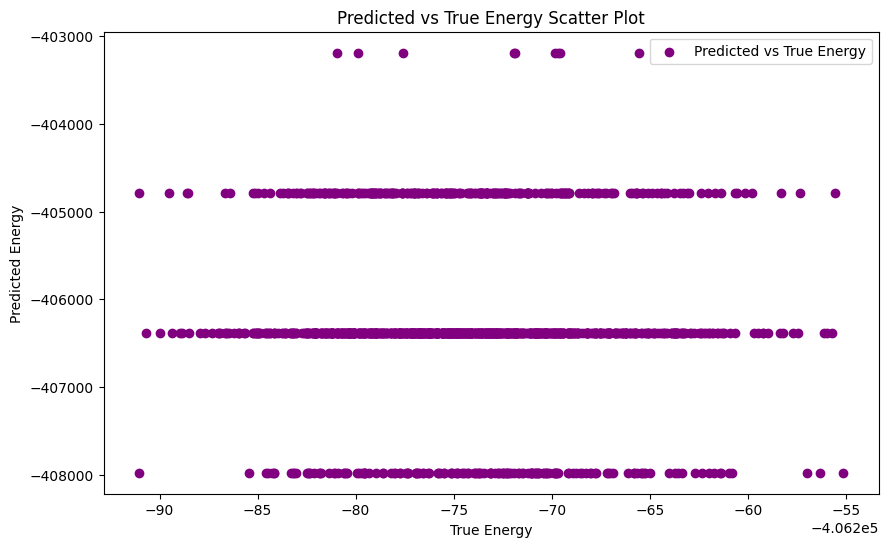

In [23]:
# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(true_energies, predicted_energies, label='Predicted vs True Energy', color='purple')
plt.xlabel('True Energy')
plt.ylabel('Predicted Energy')
plt.title('Predicted vs True Energy Scatter Plot')
plt.legend()
plt.show()